In [1]:
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# --- Martin's KNN Implementations (Unchanged) ---
def _as_float_tensor(array):
    return torch.from_numpy(array.astype(np.float32, copy=False))

def _majority_vote(nn_labels, n_classes):
    y_pred = np.empty(nn_labels.shape[0], dtype=np.int64)
    for row_idx, labels in enumerate(nn_labels):
        counts = torch.bincount(labels.long(), minlength=n_classes)
        y_pred[row_idx] = int(counts.argmax())
    return y_pred

def _weighted_vote(nn_labels, weights, n_classes):
    y_pred = np.empty(nn_labels.shape[0], dtype=np.int64)
    for row_idx, (labels, row_weights) in enumerate(zip(nn_labels, weights)):
        scores = torch.zeros(n_classes, dtype=torch.float64)
        scores.scatter_add_(0, labels.long(), row_weights.double())
        y_pred[row_idx] = int(scores.argmax())
    return y_pred

def predict_knn_euclidean(X_train, y_train, X_test, n_classes, k=5, batch_size=64, weighted=False):
    train = _as_float_tensor(X_train)
    test = _as_float_tensor(X_test)
    y_train_t = torch.from_numpy(y_train.astype(np.int64, copy=False))

    train_t = train.T.contiguous()
    train_norm = (train * train).sum(dim=1)
    y_pred = np.empty(len(X_test), dtype=y_train.dtype)

    for start_idx in range(0, len(test), batch_size):
        end_idx = min(start_idx + batch_size, len(test))
        batch = test[start_idx:end_idx]
        dists_sq = (batch * batch).sum(dim=1, keepdim=True) + train_norm[None, :] - 2 * batch.matmul(train_t)
        nn_dists_sq, nn_idx = torch.topk(dists_sq, k=k, largest=False, dim=1)
        nn_labels = y_train_t[nn_idx]

        if weighted:
            weights = 1 / (torch.sqrt(torch.clamp(nn_dists_sq, min=0)) + 1e-12)
            batch_pred = _weighted_vote(nn_labels, weights, n_classes)
        else:
            batch_pred = _majority_vote(nn_labels, n_classes)

        y_pred[start_idx:end_idx] = batch_pred
    return y_pred

def predict_knn_cosine_weighted(X_train, y_train, X_test, n_classes, k=5, batch_size=64):
    train = torch.nn.functional.normalize(_as_float_tensor(X_train), p=2, dim=1)
    test = torch.nn.functional.normalize(_as_float_tensor(X_test), p=2, dim=1)
    y_train_t = torch.from_numpy(y_train.astype(np.int64, copy=False))

    train_t = train.T.contiguous()
    y_pred = np.empty(len(X_test), dtype=y_train.dtype)

    for start_idx in range(0, len(test), batch_size):
        end_idx = min(start_idx + batch_size, len(test))
        batch = test[start_idx:end_idx]
        similarities = batch.matmul(train_t)
        nn_similarities, nn_idx = torch.topk(similarities, k=k, largest=True, dim=1)
        nn_labels = y_train_t[nn_idx]
        cosine_distances = 1 - nn_similarities
        weights = 1 / (torch.clamp(cosine_distances, min=0) + 1e-12)
        y_pred[start_idx:end_idx] = _weighted_vote(nn_labels, weights, n_classes)
    return y_pred

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/albert/.netrc.
wandb: Currently logged in as: albert-heinrichs-shop (ai-ml-universitaet-klagenfurt) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loaded X: (54616, 512), y: (54616,)
Running KNN evaluations...
[euclidean_majority] Acc: 0.2744 | Macro-F1: 0.2024 | Weighted-F1: 0.2610
[euclidean_distance_weighted] Acc: 0.2839 | Macro-F1: 0.2092 | Weighted-F1: 0.2714
[cosine_distance_weighted] Acc: 0.3009 | Macro-F1: 0.2235 | Weighted-F1: 0.2894

Best approach selected: cosine_distance_weighted (Macro-F1: 0.2235)


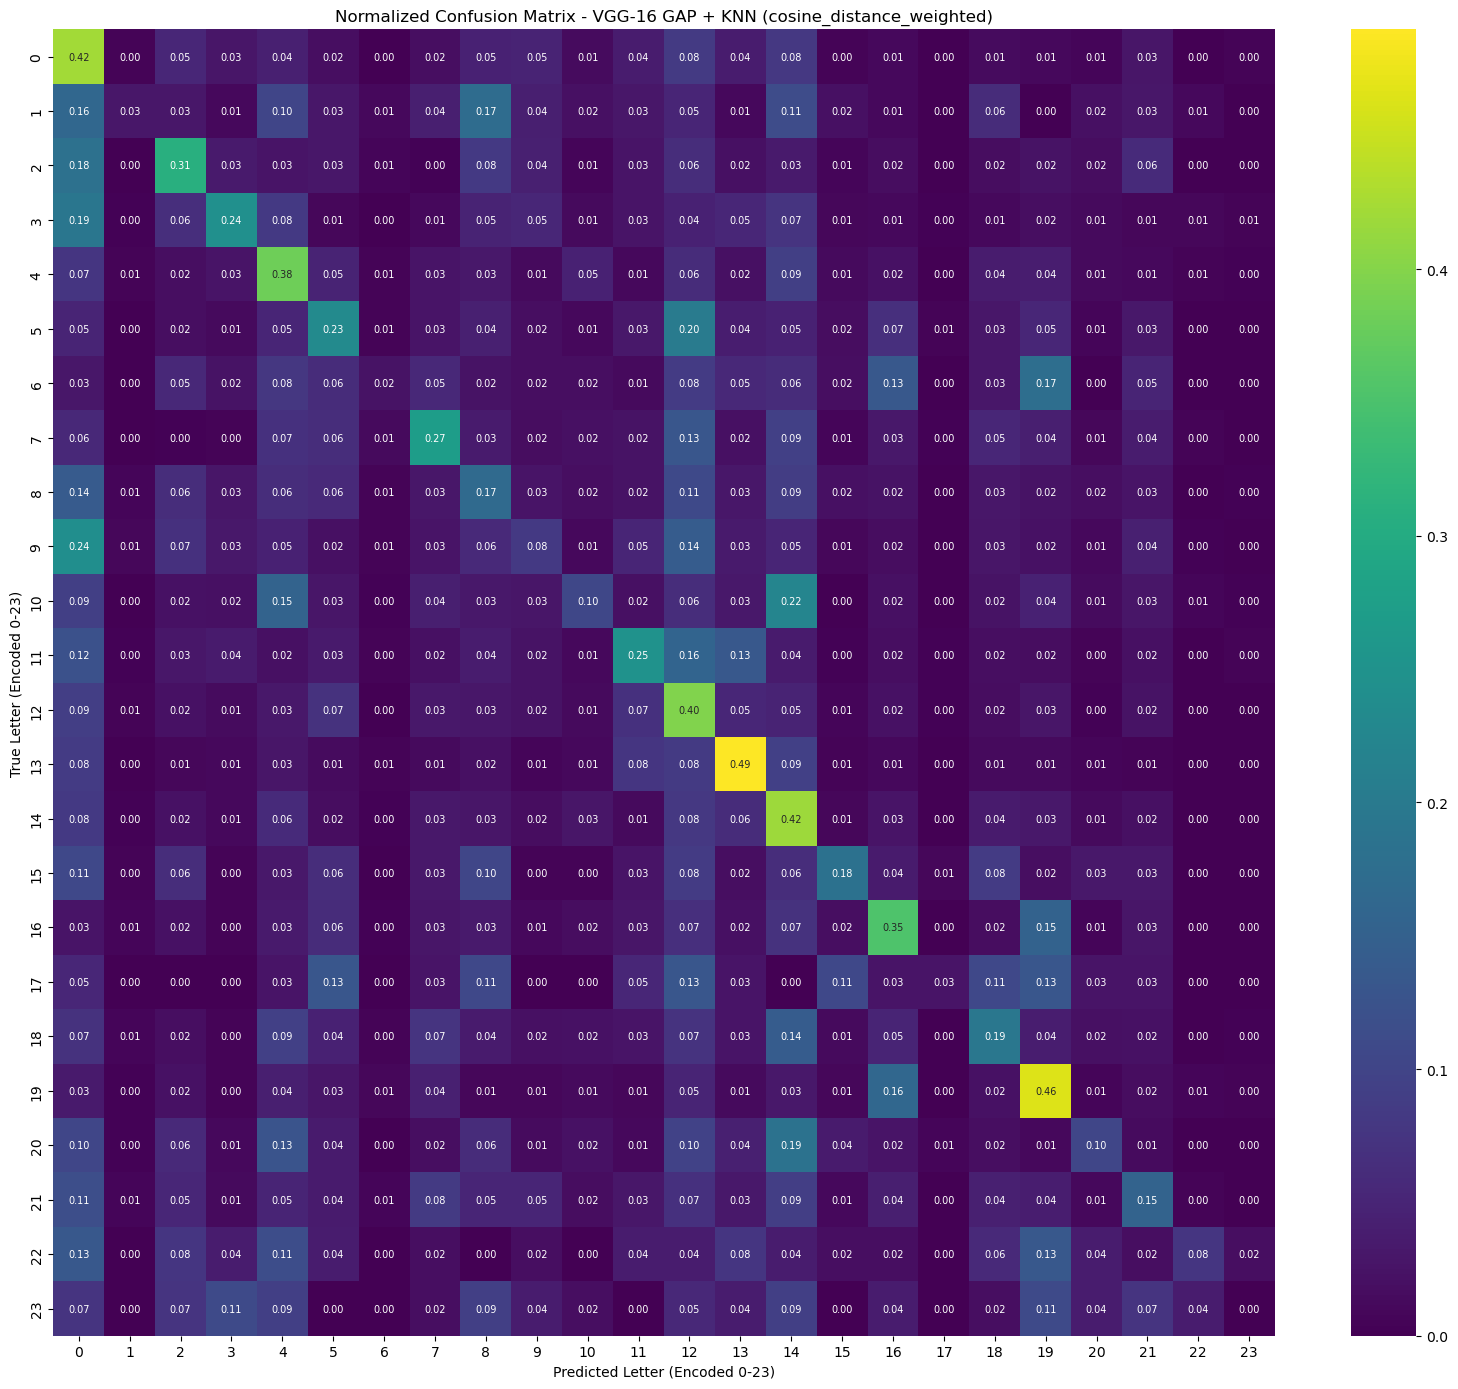


Classification Report (per class, Best Approach):
              precision    recall  f1-score   support

           0       0.32      0.42      0.37      1044
           1       0.07      0.03      0.04        99
           2       0.21      0.31      0.25       304
           3       0.34      0.24      0.28       378
           4       0.35      0.38      0.37       787
           5       0.24      0.23      0.24       533
           6       0.09      0.02      0.04       166
           7       0.26      0.27      0.27       433
           8       0.19      0.17      0.18       588
           9       0.10      0.08      0.09       355
          10       0.18      0.10      0.13       404
          11       0.27      0.25      0.26       479
          12       0.31      0.40      0.35       975
          13       0.39      0.49      0.44       543
          14       0.34      0.42      0.38       994
          15       0.27      0.18      0.22       224
          16       0.38      0

best_knn_approach,cosine_distance_weig...
cosine_distance_weighted_accuracy,0.3009
cosine_distance_weighted_macro_f1,0.22353
cosine_distance_weighted_weighted_f1,0.28939
euclidean_distance_weighted_accuracy,0.28387
euclidean_distance_weighted_macro_f1,0.20919
euclidean_distance_weighted_weighted_f1,0.27137
euclidean_majority_accuracy,0.27444
euclidean_majority_macro_f1,0.20243
euclidean_majority_weighted_f1,0.26099
+3,...


In [2]:
# 1. Config Tracking
config_params = {
    "model_type": "KNN_Comparison",
    "feature_source": "VGG16_GAP",
    "feature_dimensions": 512,  # Assuming standard VGG GAP output
    "n_neighbors": 7,
    "batch_size": 64,
    "test_size": 0.20,
    "random_state": 42
}

wandb.init(project="odysseus", name="vgg16_gap_knn_comparison", job_type="modeling", config=config_params)
config = wandb.config

# 2. Load the extracted arrays (GAP)
DATA_DIR = "../data/extracted_features"
X = np.load(f"{DATA_DIR}/X_features_vgg16.npy")
y = np.load(f"{DATA_DIR}/y_labels.npy")
n_classes = len(np.unique(y))

print(f"Loaded X: {X.shape}, y: {y.shape}")

# 3. Stratified Split & Standard Scaling (Critical for distance metrics)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.test_size, random_state=config.random_state, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Define and Run Comparisons
knn_runs = [
    {
        "name": "euclidean_majority",
        "predict": lambda: predict_knn_euclidean(X_train_scaled, y_train, X_test_scaled, n_classes, k=config.n_neighbors, batch_size=config.batch_size, weighted=False)
    },
    {
        "name": "euclidean_distance_weighted",
        "predict": lambda: predict_knn_euclidean(X_train_scaled, y_train, X_test_scaled, n_classes, k=config.n_neighbors, batch_size=config.batch_size, weighted=True)
    },
    {
        "name": "cosine_distance_weighted",
        "predict": lambda: predict_knn_cosine_weighted(X_train_scaled, y_train, X_test_scaled, n_classes, k=config.n_neighbors, batch_size=config.batch_size)
    }
]

best_macro_f1 = 0
best_approach = None
best_y_pred = None

print("Running KNN evaluations...")
for run in knn_runs:
    y_pred = run["predict"]()
    acc = accuracy_score(y_test, y_pred)
    mac_f1 = f1_score(y_test, y_pred, average='macro')
    wt_f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"[{run['name']}] Acc: {acc:.4f} | Macro-F1: {mac_f1:.4f} | Weighted-F1: {wt_f1:.4f}")
    
    # Log individual variant results to summary
    wandb.run.summary[f"{run['name']}_accuracy"] = acc
    wandb.run.summary[f"{run['name']}_macro_f1"] = mac_f1
    wandb.run.summary[f"{run['name']}_weighted_f1"] = wt_f1
    
    if mac_f1 > best_macro_f1:
        best_macro_f1 = mac_f1
        best_approach = run['name']
        best_y_pred = y_pred
        wandb.run.summary["final_accuracy"] = acc
        wandb.run.summary["final_macro_f1"] = mac_f1
        wandb.run.summary["final_weighted_f1"] = wt_f1

wandb.run.summary["best_knn_approach"] = best_approach
print(f"\nBest approach selected: {best_approach} (Macro-F1: {best_macro_f1:.4f})")

# 5. Generate and Log Annotated Heatmap for the Best Approach
cm = confusion_matrix(y_test, best_y_pred, normalize='true')

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="viridis", cbar=True, annot_kws={"size": 7})

plt.title(f"Normalized Confusion Matrix - VGG-16 GAP + KNN ({best_approach})")
plt.xlabel("Predicted Letter (Encoded 0-23)")
plt.ylabel("True Letter (Encoded 0-23)")
plt.tight_layout()

plt.savefig("knn_gap_confusion_matrix.png", dpi=300)
wandb.log({"confusion_matrix_annotated": wandb.Image("knn_gap_confusion_matrix.png")})
plt.show()

print("\nClassification Report (per class, Best Approach):")
print(classification_report(y_test, best_y_pred))

wandb.finish()

In [ ]:
# 1. Config Tracking
config_params = {
    "model_type": "KNN_Comparison",
    "feature_source": "VGG16_SPP_2x2",
    "feature_dimensions": 2048,  # SPP dimensions
    "n_neighbors": 7,
    "batch_size": 64,
    "test_size": 0.20,
    "random_state": 42
}

wandb.init(project="odysseus", name="vgg16_spp2x2_knn_comparison", job_type="modeling", config=config_params)
config = wandb.config

# 2. Load the extracted arrays (SPP)
DATA_DIR = "../data/extracted_features_SPP"
X = np.load(f"{DATA_DIR}/X_features_vgg16.npy")
y = np.load(f"{DATA_DIR}/y_labels.npy")
n_classes = len(np.unique(y))

print(f"Loaded X: {X.shape}, y: {y.shape}")

# 3. Stratified Split & Standard Scaling 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.test_size, random_state=config.random_state, stratify=y
)

# Standard scaling is heavily advised here to prevent certain dimensional variances in SPP from dominating distances
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Define and Run Comparisons
knn_runs = [
    {
        "name": "euclidean_majority",
        "predict": lambda: predict_knn_euclidean(X_train_scaled, y_train, X_test_scaled, n_classes, k=config.n_neighbors, batch_size=config.batch_size, weighted=False)
    },
    {
        "name": "euclidean_distance_weighted",
        "predict": lambda: predict_knn_euclidean(X_train_scaled, y_train, X_test_scaled, n_classes, k=config.n_neighbors, batch_size=config.batch_size, weighted=True)
    },
    {
        "name": "cosine_distance_weighted",
        "predict": lambda: predict_knn_cosine_weighted(X_train_scaled, y_train, X_test_scaled, n_classes, k=config.n_neighbors, batch_size=config.batch_size)
    }
]

best_macro_f1 = 0
best_approach = None
best_y_pred = None

print("Running KNN evaluations on 2048-D SPP vectors...")
for run in knn_runs:
    y_pred = run["predict"]()
    acc = accuracy_score(y_test, y_pred)
    mac_f1 = f1_score(y_test, y_pred, average='macro')
    wt_f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"[{run['name']}] Acc: {acc:.4f} | Macro-F1: {mac_f1:.4f} | Weighted-F1: {wt_f1:.4f}")
    
    wandb.run.summary[f"{run['name']}_accuracy"] = acc
    wandb.run.summary[f"{run['name']}_macro_f1"] = mac_f1
    wandb.run.summary[f"{run['name']}_weighted_f1"] = wt_f1
    
    if mac_f1 > best_macro_f1:
        best_macro_f1 = mac_f1
        best_approach = run['name']
        best_y_pred = y_pred
        wandb.run.summary["final_accuracy"] = acc
        wandb.run.summary["final_macro_f1"] = mac_f1
        wandb.run.summary["final_weighted_f1"] = wt_f1

wandb.run.summary["best_knn_approach"] = best_approach
print(f"\nBest approach selected: {best_approach} (Macro-F1: {best_macro_f1:.4f})")

# 5. Generate and Log Annotated Heatmap for the Best Approach
cm = confusion_matrix(y_test, best_y_pred, normalize='true')

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="viridis", cbar=True, annot_kws={"size": 7})

plt.title(f"Normalized Confusion Matrix - VGG-16 SPP + KNN ({best_approach})")
plt.xlabel("Predicted Letter (Encoded 0-23)")
plt.ylabel("True Letter (Encoded 0-23)")
plt.tight_layout()

plt.savefig("knn_spp_confusion_matrix.png", dpi=300)
wandb.log({"confusion_matrix_annotated": wandb.Image("knn_spp_confusion_matrix.png")})
plt.show()

print("\nClassification Report (per class, Best Approach):")
print(classification_report(y_test, best_y_pred))

wandb.finish()

Loaded X: (125280, 2048), y: (125280,)
Running KNN evaluations on 2048-D SPP vectors...
